<a href="https://colab.research.google.com/github/ankitsingh435517/nn/blob/main/micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementing the micrograd as is from memory

In [ ]:
import math

class Value:
  """A Value class that will hold the scalar value inside of a neuron"""
  def __init__(self, data, _children=(), op=""):
    self.data = data
    self.grad = 0.0 # default initialized to 0.0
    self._prev = _children
    self._op = op

  def __repr__(self):
    return f'Value(data={self.data})'

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), "+")
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")
    return out

  def _tanh(self, out):
    return math.tanh(out)

  # it calls tanh on weighted sum and bias received.
  def _squash(self, bias=0):
    # self.data is the output of the entire expression aka weighted sum
    out = self._tanh(self.data + bias)
    return out

In [ ]:
a = Value(3);
print(a)

Value(data=3)


Now i have the simple Value class to work with floats and ints scalars, let's extend it to allow mathematical operations so that we can create mathematical expressions.

In [ ]:
b = Value(2);
c = a * b;
c

Value(data=6)

Now we have the add method which adds to Value scalar object and returns a new Value scalar object as the output, but it's not enough for us to know what expression got us this output and how to do the gradient as we need to know the nodes in the expression, so we will need a way to store the operands and operator as nodes

Now we added the children and operation label, now we are good to represent a mathematical epxression so that we can visualize it.

In [ ]:
from graphviz import Digraph
# dag traversal
def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
    for child in v._prev:
      edges.add((child, v))
      build(child)

  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format="svg", graph_attr={"rankdir":"LR"})

  nodes, edges = trace(root)
  # draw all nodes & operations and point op to the node
  for n in nodes:
    uid = str(id(n))
    dot.node(name=uid, label="{ data | %.4f }" % (n.data, ), shape="record")
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)

  # point each child to its parent's op node
  for child, parent in edges:
    dot.edge(str(id(child)), str(id(parent)) + parent._op)

  return dot


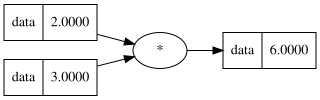

In [ ]:
draw_dot(c)

In [ ]:
d = Value(4)
o = d + c
o

Value(data=10)

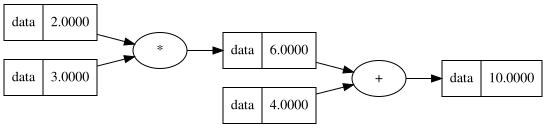

In [ ]:
draw_dot(o)

couldn't make the draw_dot function work on my own, copied from micrograd video.
Anyways moving on - now we have the viz for the mathematical expression so far.
Let's move on and add support for multiplication.

Now that we have mul and add we can make use of dot product and addition, we need now a bias and a squashing function to get the final output of the neuron which is for all inputs and their weights we need f(sum(wi * xi) + b). This makes up a single forward pass. then we would need grad for backward pass or backprop.

Next we will add a bias in the final output - but where ? and what will become x and w ? and what is meant by weighted sum in the current mathematical expression ?

There is a data Value object and then a weight Value object now for an expression where b is a data and c is weight and a = b * c and then a is a weight*data or w1*x1 then we take that and then add it to d = a + e here e suppose is a data and then d = w1x1 + x2 now doees e has to be a dot product with some weight f ? to make the final output d = w1x1 + w2x2 then this d needs a bias say y then our output o = d + y which is w1x1 + w2x2 + b then o needs to be passed in a squashing function like tanh then that value output is L that has to be found the loss by a loss function like a mean squared error loss function.

Its not necessary x2 needs its weight w2 but a general neuron usually has, but micrograd doesn't. so leaving it as is and then modify and see what changes in the network.

so now we need to add a function which takes in the sum as the value and adds the bias then squashes the output.

Then that output needs to be passed to mean squred error function which gives us the loss which can be used to nudge how much the gradient in backprop.

If the bias has to be randomly initialized and then gets updated on backprop then where will it be saved ? i am passing it to the call function

In [ ]:
# create x1w1 + x2 and then pass it to squash method to get output of the neuron
# x1w1 is the result of a = b * c
# x2 is d so o is the entire weighted sum
y = o._squash()
y

0.9999999958776927

In [ ]:
# now get the error offset using mean squared error (mean squared error penalizes large errors heavily so for classification its not the best loss function)
# but the loss has to be calculated and then we need to use that loss to nudge how much
yi = 0.9999999999999999
loss = math.pow((yi - y), 2)
loss

1.699341634027481e-17

In [ ]:
# now we need to do the backprop
# how is a local grad created
# we need local grad as well as an upstream grad
# what is a grad ? a gradient is a derivative of an output to its child with respect to operation it is involved in
# example a = b * c
# here derivative of b with respect to c is db/dc here the derivative of db/dc in a product is the constant multiplier becomes 1 and so b is the derivative

-----------------------First Iteration: In 2 days i could only build forward pass not so confidently.-----------------------

<!-- In 2 days i could only build forward pass not very confidently. -->

Learnings are:


1.   Forward pass almost clear with some revisit needed on activation function and bias significance and when to add it.
2.   Backprop not very clear, local & upstream gradient impl is not coherent as of now.
3. A single Value to Neuron is not clear, A single layer as well as MLP
4. Don't recall how to make up a neural net
5. training & prediction is not clear on what target to use for a single neuron and a neural net ?

